 STUDENT PERFORMANCE PREDICTION
Model Accuracy: 100.0 %

Enter New Student Details


Student Name:  saga
Study Hours:  3
Attendance (%):  98
Internal Marks:  99
Previous Exam Mark:  98



         STUDENT RESULT
Name              : saga
Study Hours       : 3.0
Attendance        : 98.0 %
Internal Marks    : 99.0
Previous Mark     : 98.0
Performance Score : 113.4
Class Average     : 78.9
Difference        : 34.5
Comparison        : Above Class Average
Predicted Result  : PASS
Rank              : 2 out of 13


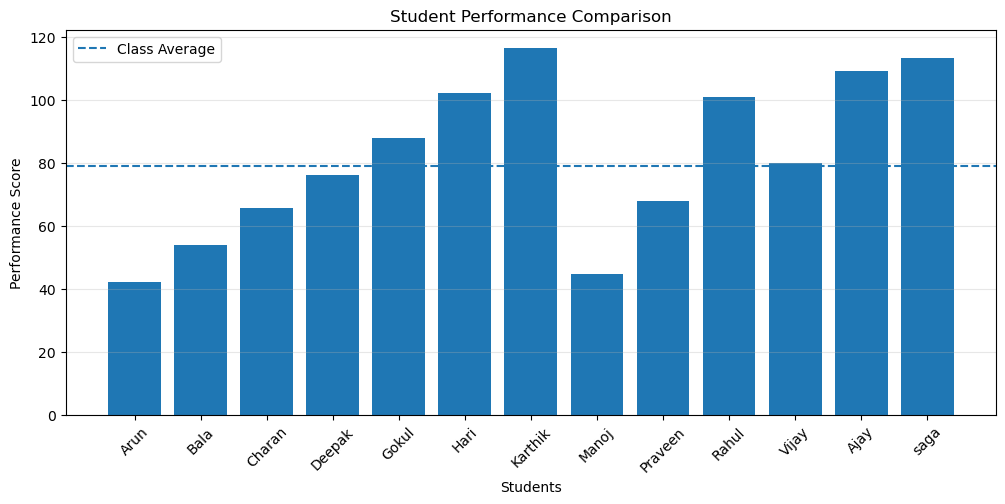

In [3]:
# STUDENT PERFORMANCE PREDICTION & COMPARISON
# Machine Learning Mini Project

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---------------- DATASET ----------------

data = {
    "Name": ["Arun","Bala","Charan","Deepak","Gokul","Hari",
             "Karthik","Manoj","Praveen","Rahul","Vijay","Ajay"],

    "StudyHours": [2,3,4,5,6,7,8,2,4,6,5,7],

    "Attendance": [55,60,68,72,80,85,92,58,70,88,75,90],

    "InternalMarks": [28,35,42,48,55,65,75,30,45,68,52,72],

    "PreviousMark": [25,32,38,44,50,60,70,28,40,65,48,68],

    "Result": [0,0,0,1,1,1,1,0,0,1,1,1]
}

df = pd.DataFrame(data)

# ---------------- PERFORMANCE SCORE ----------------

df["Performance"] = (
    df["StudyHours"] * 5 +
    df["Attendance"] * 0.2 +
    df["InternalMarks"] * 0.4 +
    df["PreviousMark"] * 0.4
).round(2)

# ---------------- MACHINE LEARNING ----------------

X = df[["StudyHours","Attendance","InternalMarks","PreviousMark"]]
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, model.predict(X_test))

print("======================================")
print(" STUDENT PERFORMANCE PREDICTION")
print("======================================")
print("Model Accuracy:", round(accuracy * 100, 2), "%")

# ---------------- NEW STUDENT INPUT ----------------

print("\nEnter New Student Details")

name = input("Student Name: ")
study = float(input("Study Hours: "))
attendance = float(input("Attendance (%): "))
internal = float(input("Internal Marks: "))
previous = float(input("Previous Exam Mark: "))

# Prediction
new_student = pd.DataFrame({
    "StudyHours": [study],
    "Attendance": [attendance],
    "InternalMarks": [internal],
    "PreviousMark": [previous]
})

prediction = model.predict(new_student)[0]

result = "PASS" if prediction == 1 else "FAIL"

# Performance score
new_performance = round(
    study * 5 +
    attendance * 0.2 +
    internal * 0.4 +
    previous * 0.4, 2
)

# ---------------- COMPARISON ----------------

class_average = round(df["Performance"].mean(), 2)

difference = round(
    new_performance - class_average, 2
)

if difference > 0:
    comparison = "Above Class Average"
elif difference < 0:
    comparison = "Below Class Average"
else:
    comparison = "Equal to Class Average"

# Rank
rank = 1 + sum(
    df["Performance"] > new_performance
)

# ---------------- OUTPUT ----------------

print("\n======================================")
print("         STUDENT RESULT")
print("======================================")

print("Name              :", name)
print("Study Hours       :", study)
print("Attendance        :", attendance, "%")
print("Internal Marks    :", internal)
print("Previous Mark     :", previous)
print("Performance Score :", new_performance)
print("Class Average     :", class_average)
print("Difference        :", difference)
print("Comparison        :", comparison)
print("Predicted Result  :", result)
print("Rank              :", rank, "out of", len(df) + 1)

# ---------------- ADD NEW STUDENT ----------------

new_row = pd.DataFrame({
    "Name": [name],
    "StudyHours": [study],
    "Attendance": [attendance],
    "InternalMarks": [internal],
    "PreviousMark": [previous],
    "Result": [prediction],
    "Performance": [new_performance]
})

df = pd.concat([df, new_row], ignore_index=True)

# ---------------- VISUALIZATION ----------------

plt.figure(figsize=(12, 5))

plt.bar(df["Name"], df["Performance"])

plt.axhline(
    class_average,
    linestyle="--",
    label="Class Average"
)

plt.xlabel("Students")
plt.ylabel("Performance Score")
plt.title("Student Performance Comparison")

plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()